# Seven input formats, one TopoKit workflow

This notebook demonstrates that TopoKit reads seven structural file formats into the same `PointCloud` interface. Each section starts from one file, reports the resulting `PointCloud`, and applies the same H0/H1 and L0/L1 workflow.

The common mathematical path is:

`readers.read` → Hyperdigraph filtration → H0/H1 persistence → L0/L1 spectra → spectral postprocessing.

> These fixtures describe different scientific objects. The examples demonstrate a shared API, not numerical agreement between formats.

## Demo inputs

| Format | File read in its section | Points used in the tutorial analysis |
| --- | --- | --- |
| PDB | `data_6PT3_ligand.pdb` | all 36 atoms |
| MOL2 | `data_6PT3_ligand.mol2` | all 36 atoms |
| SDF | `data_molecule.sdf` | all 36 atoms |
| MOL | `data_molecule.mol` | all 24 atoms |
| PDBQT | `data_protein.pdbqt` | first 24 of 3,646 atoms |
| CIF | `AQUCOG_clean.cif` | first 24 of 162 atom sites |
| JSON | `data_material_from_cif.json` | all 29 points |

PDBQT and CIF are parsed in full; their analyses use the first 24 points to keep runtime short.

In [1]:
%matplotlib inline
from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Work when Jupyter starts in either topokit/ or topokit/examples/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src' / 'topokit').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src' / 'topokit').is_dir():
    raise RuntimeError('Start Jupyter in topokit/ or topokit/examples/.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from topokit import builders, core, postprocessing, readers, workflows
from topokit import visualization as viz

DATA_DIR = PROJECT_ROOT / 'examples' / 'data'
DIMENSIONS = (0, 1)
STATISTICS = ('min', 'max', 'mean', 'laplacian_energy')
N_LAPLACIAN_SCALES = 6
N_BETTI_SCALES = 100

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 8, 'axes.titlesize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False, 'axes.grid': False,
})

## Shared, small analysis helpers

The helpers below accept an already-read `PointCloud` and apply a common analysis and plotting recipe. Candidate edges are all point pairs. The inclusive cutoff is 1.8 times the median nearest-neighbor distance, six scales are used for the more expensive ordinary Laplacians, and 100 inexpensive persistence queries give smooth Betti step curves.

Construction uses `max_dimension=1`, while TopoKit retains the degree-2 boundary information needed for H1 deaths and complete L1. Persistence is computed over GF(2); Laplacian spectra are real. Infinite bars are right-censored at this notebook's finite cutoff.

In [2]:
def inspect_cloud(name, cloud):
    labels = cloud.metadata.get('labels', ())
    units = cloud.metadata.get('coordinate_units', 'unspecified')
    print(f'{name}: {len(cloud)} points, shape={cloud.points.shape}, units={units}')
    print('  first IDs:', cloud.ids[:5])
    print('  first coordinate:', np.round(cloud.points[0], 4))
    if labels:
        print('  point labels:', sorted(set(labels)))
    print('  first weights:', np.round(cloud.weights[:5], 4))


def analyze_cloud(cloud):
    distances = np.linalg.norm(
        cloud.points[:, None, :] - cloud.points[None, :, :], axis=2
    )
    positive_distances = np.where(distances > 0.0, distances, np.inf)
    nearest = np.min(positive_distances, axis=1)
    cutoff = 1.8 * float(np.median(nearest[np.isfinite(nearest)]))
    scales = np.linspace(0.0, cutoff, N_LAPLACIAN_SCALES)
    betti_scales = np.linspace(0.0, cutoff, N_BETTI_SCALES)

    topology = builders.from_points(
        cloud,
        kind='hyperdigraph',
        max_dimension=1,
        bonds=tuple(combinations(cloud.ids, 2)),
        cutoff=cutoff,
        max_scale=cutoff,
    )
    bars = core.persistence(topology, max_dimension=1)
    laplacians = workflows.laplacian_series(
        topology, max_dimension=1, scales=scales
    )
    summaries = {
        scale: {
            q: postprocessing.summarize_spectrum(
                laplacians[scale][q],
                statistics=STATISTICS,
                positive_only=False,
                empty_operator_policy='zero',
            )
            for q in DIMENSIONS
        }
        for scale in scales
    }

    assert bars.max_dimension == 1
    for scale in scales:
        for q in DIMENSIONS:
            assert laplacians[scale][q].complete
            assert summaries[scale][q].names == tuple(
                f'L{q}:{statistic}' for statistic in STATISTICS
            )
            assert np.all(np.isfinite(summaries[scale][q].values))
    return {
        'cloud': cloud, 'topology': topology, 'bars': bars,
        'laplacians': laplacians, 'summaries': summaries,
        'scales': scales, 'betti_scales': betti_scales, 'cutoff': cutoff,
    }

In [3]:
def plot_analysis(title, analysis):
    cloud = analysis['cloud']
    bars = analysis['bars']
    scales = analysis['scales']
    betti_scales = analysis['betti_scales']
    units = cloud.metadata['coordinate_units']

    print(f"cutoff={analysis['cutoff']:.3f} {units}; "
          f"{len(bars.intervals)} persistence intervals; dimensions H0/H1 and L0/L1")
    figure, axes = plt.subplots(2, 2, figsize=(9.2, 6.4), constrained_layout=True)

    viz.plot_barcodes(
        bars, ax=axes[0, 0], title='H0/H1 barcodes',
        mark_initial_stage=False,
    )
    axes[0, 0].set_xlabel(f'Distance cutoff [{units}]')

    viz.plot_betti_curves(
        bars, betti_scales, dimensions=DIMENSIONS, ax=axes[0, 1],
        title='Betti curves over GF(2)',
        xlabel=f'Distance cutoff [{units}]',
    )

    for q, axis in zip(DIMENSIONS, axes[1]):
        summaries = [analysis['summaries'][scale][q] for scale in scales]
        viz.plot_spectral_summary_series(
            summaries, scales=scales, ax=axis,
            statistics=('min', 'max', 'mean'),
            energy='laplacian_energy',
            title=f'L{q} spectral summaries',
            xlabel=f'Distance cutoff [{units}]',
        )

    figure.suptitle(f'{title} · {len(cloud)} analysis points')
    plt.show()

## 1. PDB

Read the 6PT3 ligand from its PDB record, then assign element-based weights for Hyperdigraph orientation.

In [4]:
pdb_source = readers.read(DATA_DIR / 'data_6PT3_ligand.pdb')
pdb_cloud = readers.assign_element_weights(pdb_source)
inspect_cloud('PDB input', pdb_cloud)

PDB input: 36 points, shape=(36, 3), units=angstrom
  first IDs: (1, 2, 3, 4, 5)
  first coordinate: [  2.438 -40.25  -54.794]
  point labels: ['C', 'N', 'O']
  first weights: [2.55 2.55 3.04 2.55 2.55]


cutoff=2.538 angstrom; 68 persistence intervals; dimensions H0/H1 and L0/L1


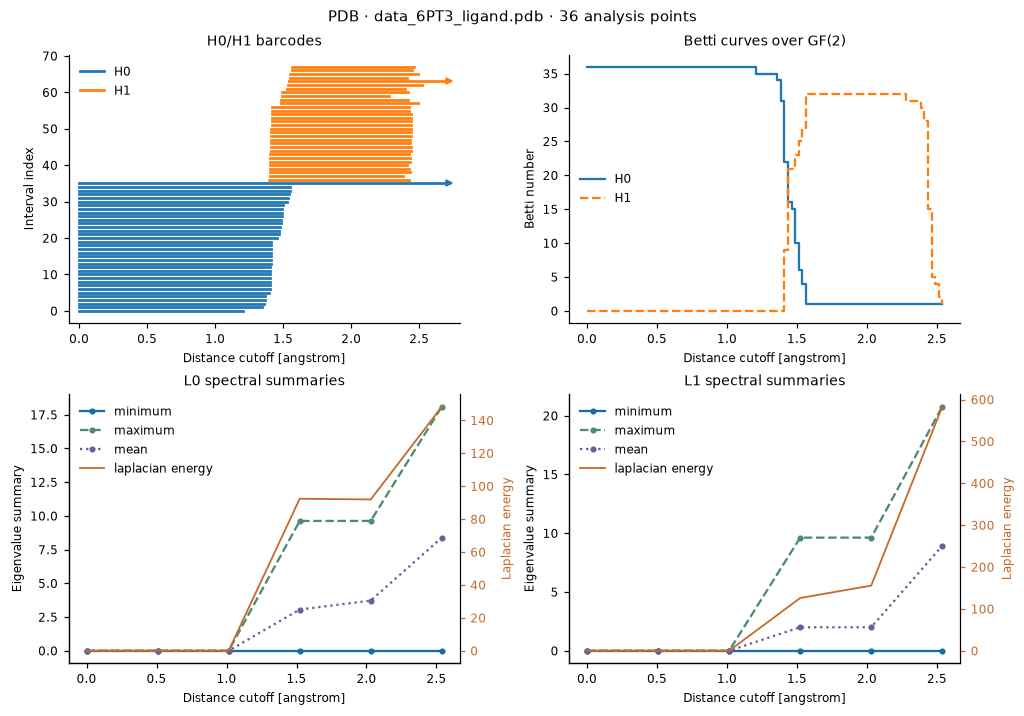

In [5]:
pdb_analysis = analyze_cloud(pdb_cloud)
plot_analysis('PDB · data_6PT3_ligand.pdb', pdb_analysis)

## 2. MOL2

The MOL2 representation of the 6PT3 ligand is analyzed using all 36 atoms.

In [6]:
mol2_source = readers.read(DATA_DIR / 'data_6PT3_ligand.mol2')
mol2_cloud = readers.assign_element_weights(mol2_source)
inspect_cloud('MOL2 input', mol2_cloud)

MOL2 input: 36 points, shape=(36, 3), units=angstrom
  first IDs: (1, 2, 3, 4, 5)
  first coordinate: [  2.438 -40.25  -54.794]
  point labels: ['C', 'N', 'O']
  first weights: [2.55 2.55 3.04 2.55 2.55]


cutoff=2.538 angstrom; 68 persistence intervals; dimensions H0/H1 and L0/L1


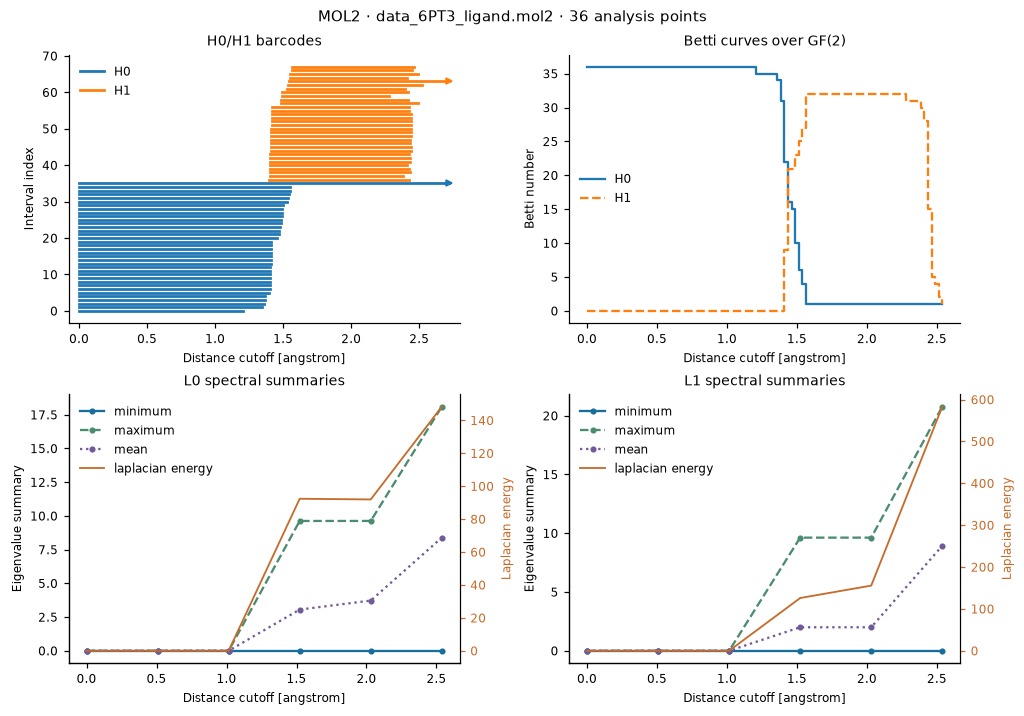

In [7]:
mol2_analysis = analyze_cloud(mol2_cloud)
plot_analysis('MOL2 · data_6PT3_ligand.mol2', mol2_analysis)

## 3. SDF

Read one SDF molecule. TopoKit preserves its atom and property metadata while exposing the coordinates as a `PointCloud`.

In [8]:
sdf_source = readers.read(DATA_DIR / 'data_molecule.sdf')
sdf_cloud = readers.assign_element_weights(sdf_source)
inspect_cloud('SDF input', sdf_cloud)

SDF input: 36 points, shape=(36, 3), units=angstrom
  first IDs: (1, 2, 3, 4, 5)
  first coordinate: [ 0.8334 -2.9412 -0.2739]
  point labels: ['C', 'H', 'N', 'O', 'S']
  first weights: [2.55 2.55 2.55 2.55 2.55]


cutoff=1.963 angstrom; 50 persistence intervals; dimensions H0/H1 and L0/L1


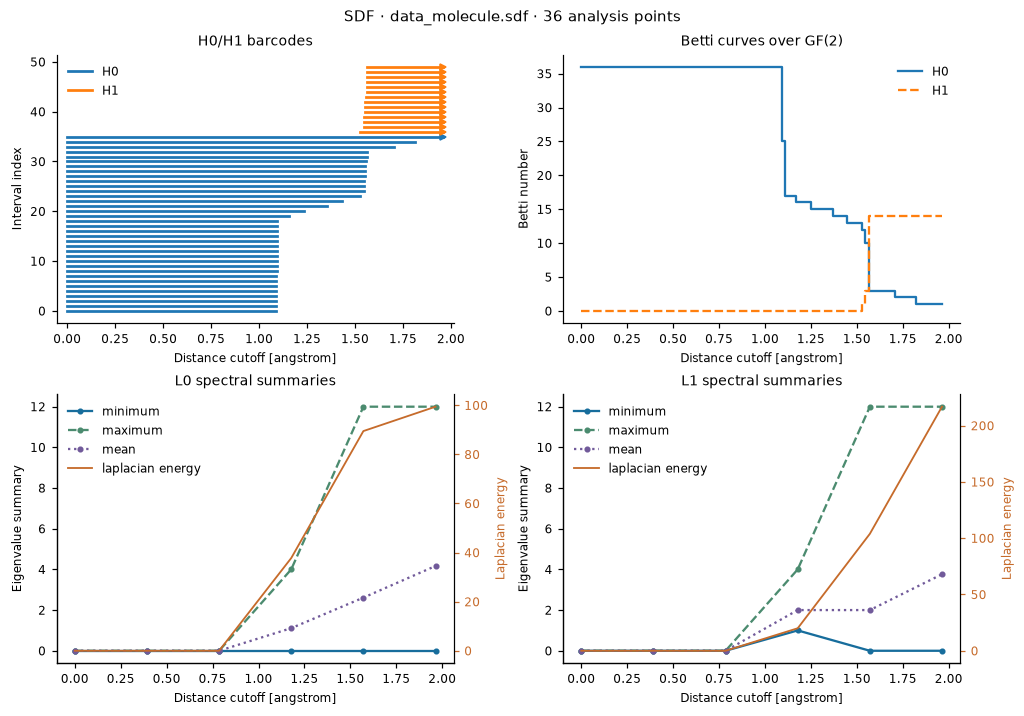

In [9]:
sdf_analysis = analyze_cloud(sdf_cloud)
plot_analysis('SDF · data_molecule.sdf', sdf_analysis)

## 4. MOL

Read the MOL fixture and analyze all 24 atoms.

In [10]:
mol_source = readers.read(DATA_DIR / 'data_molecule.mol')
mol_cloud = readers.assign_element_weights(mol_source)
inspect_cloud('MOL input', mol_cloud)

MOL input: 24 points, shape=(24, 3), units=angstrom
  first IDs: (1, 2, 3, 4, 5)
  first coordinate: [-0.6679  1.1587  0.257 ]
  point labels: ['C', 'H', 'O']
  first weights: [3.44 3.44 3.44 3.44 3.44]


cutoff=1.970 angstrom; 30 persistence intervals; dimensions H0/H1 and L0/L1


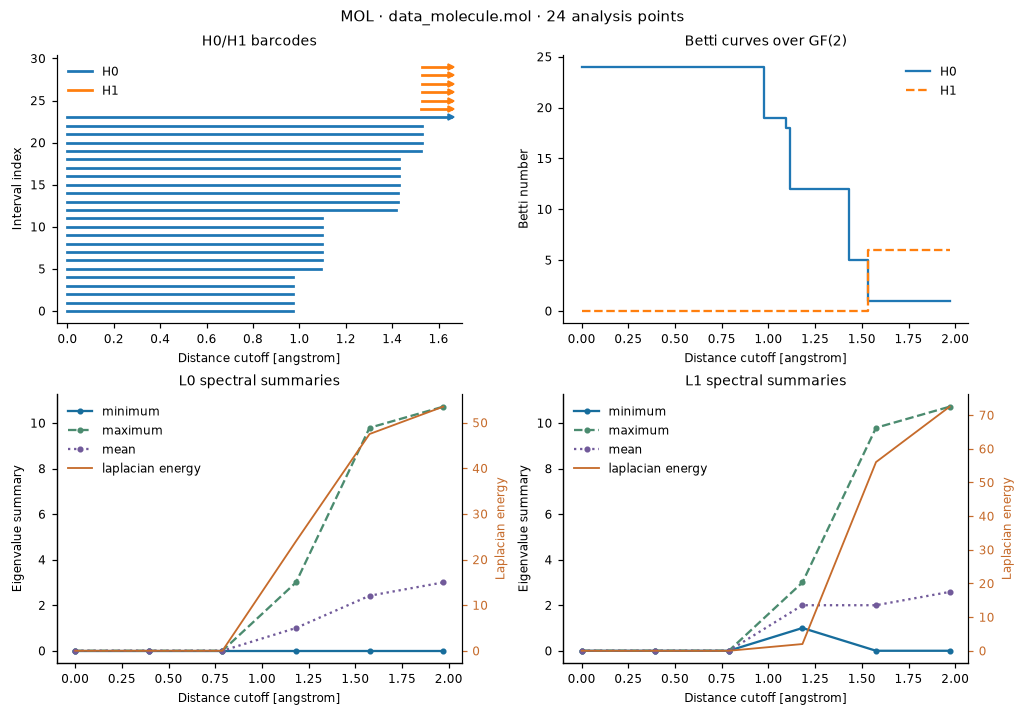

In [11]:
mol_analysis = analyze_cloud(mol_cloud)
plot_analysis('MOL · data_molecule.mol', mol_analysis)

## 5. PDBQT

The PDBQT reader loads all 3,646 receptor atoms, including docking atom types and charges. The analysis uses the first 24 atoms as a deterministic tutorial subset.

In [12]:
pdbqt_source = readers.read(DATA_DIR / 'data_protein.pdbqt')
inspect_cloud('PDBQT full input', pdbqt_source)
pdbqt_selected = pdbqt_source.subset(pdbqt_source.ids[:24])
pdbqt_cloud = readers.assign_element_weights(pdbqt_selected)
inspect_cloud('PDBQT analysis subset', pdbqt_cloud)

PDBQT full input: 3646 points, shape=(3646, 3), units=angstrom
  first IDs: (1, 2, 3, 4, 5)
  first coordinate: [ -7.454 -38.807 -71.822]
  point labels: ['C', 'H', 'N', 'O', 'S']
  first weights: [1. 1. 1. 1. 1.]
PDBQT analysis subset: 24 points, shape=(24, 3), units=angstrom
  first IDs: (1, 2, 3, 4, 5)
  first coordinate: [ -7.454 -38.807 -71.822]
  point labels: ['C', 'N', 'O', 'S']
  first weights: [3.04 2.55 2.55 3.44 2.55]


cutoff=2.579 angstrom; 33 persistence intervals; dimensions H0/H1 and L0/L1


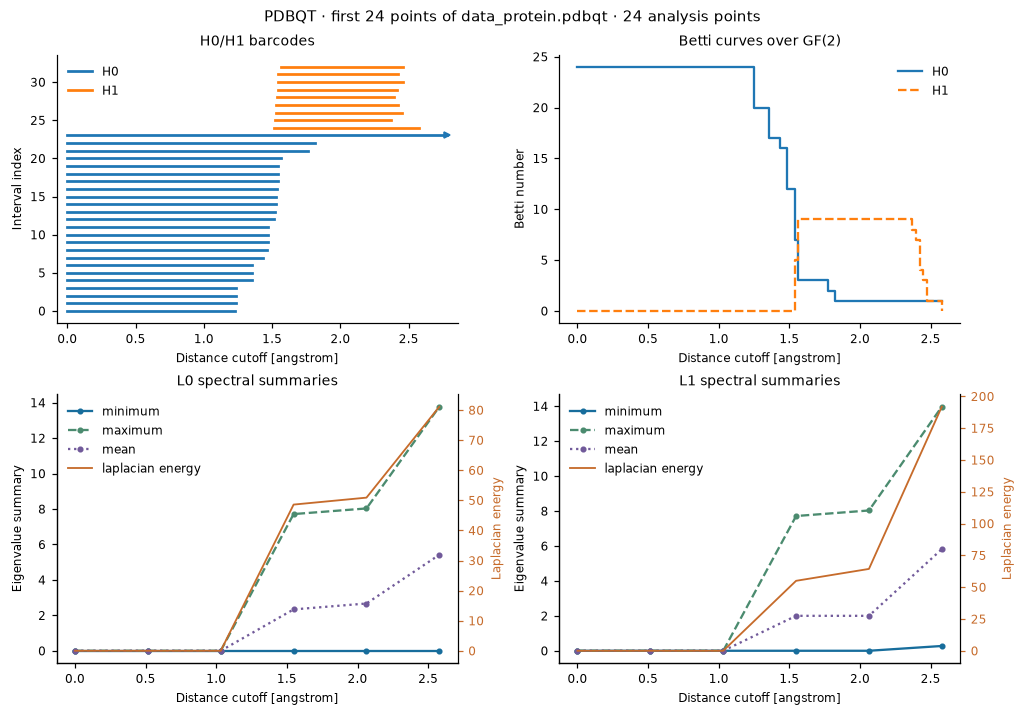

In [13]:
pdbqt_analysis = analyze_cloud(pdbqt_cloud)
plot_analysis('PDBQT · first 24 points of data_protein.pdbqt', pdbqt_analysis)

## 6. CIF: AQUCOG

`AQUCOG_clean.cif` is the computation-ready, all-solvent-removed CoRE MOF derivative of CSD refcode AQUCOG, sourced from the [CC BY 4.0 CoRE MOF 2019 archive](https://doi.org/10.5281/zenodo.7691378). The file stores 162 symmetry-expanded P1 fractional atom sites; the reader converts them to Cartesian ångström coordinates and retains the original fractional fields and unit cell in metadata. The first 24 sites are used for the tutorial analysis.

In [14]:
cif_source = readers.read(DATA_DIR / 'AQUCOG_clean.cif')
inspect_cloud('CIF full input', cif_source)
print('  unit cell:', cif_source.metadata['unit_cell'])
cif_selected = cif_source.subset(cif_source.ids[:24])
cif_cloud = readers.assign_element_weights(cif_selected)
inspect_cloud('CIF analysis subset', cif_cloud)

CIF full input: 162 points, shape=(162, 3), units=angstrom
  first IDs: ('Ni1', 'O1', 'O2', 'O3', 'C1')
  first coordinate: [ 7.5894 14.45    2.3838]
  point labels: ['C', 'H', 'Ni', 'O']
  first weights: [1. 1. 1. 1. 1.]
  unit cell: {'length_a': 25.7542, 'length_b': 25.7542, 'length_c': 6.755, 'angle_alpha': 90.0, 'angle_beta': 90.0, 'angle_gamma': 120.0}
CIF analysis subset: 24 points, shape=(24, 3), units=angstrom
  first IDs: ('Ni1', 'O1', 'O2', 'O3', 'C1')
  first coordinate: [ 7.5894 14.45    2.3838]
  point labels: ['C', 'H', 'Ni', 'O']
  first weights: [1.91 3.44 3.44 3.44 2.55]


cutoff=2.405 angstrom; 31 persistence intervals; dimensions H0/H1 and L0/L1


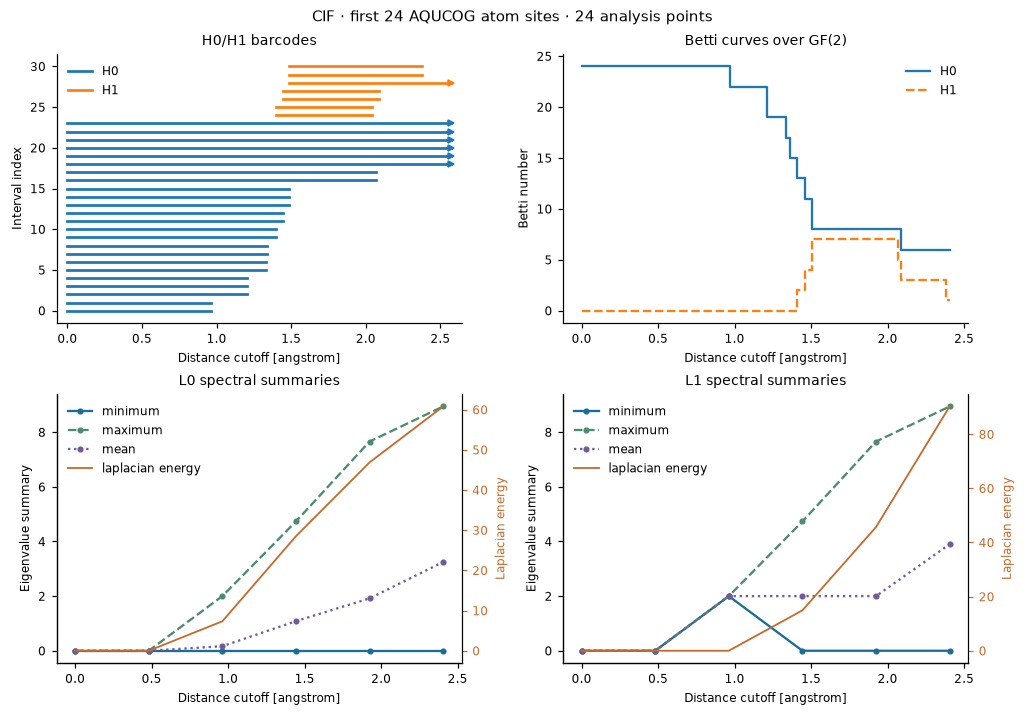

In [15]:
cif_analysis = analyze_cloud(cif_cloud)
plot_analysis('CIF · first 24 AQUCOG atom sites', cif_analysis)

## 7. JSON

The native JSON point-cloud schema requires `coordinates` and can optionally carry one `labels` and one `weights` value per point. This fixture contains Cartesian coordinates derived from `data_material.cif`, plus its point labels and explicit element weights. The supplied weights are used directly in the Hyperdigraph construction.

In [16]:
json_cloud = readers.read(DATA_DIR / 'data_material_from_cif.json')
inspect_cloud('JSON input', json_cloud)
print('  schema:', json_cloud.metadata['json_schema'],
      'version', json_cloud.metadata['json_schema_version'])

JSON input: 29 points, shape=(29, 3), units=angstrom
  first IDs: ('Ni1', 'Br1', 'P1', 'C1', 'C11')
  first coordinate: [11.4398  8.1146  0.2279]
  point labels: ['B', 'Br', 'C', 'H', 'Ni', 'P']
  first weights: [1.91 2.96 2.19 2.55 2.55]
  schema: topokit.point_cloud version 1


cutoff=1.980 angstrom; 33 persistence intervals; dimensions H0/H1 and L0/L1


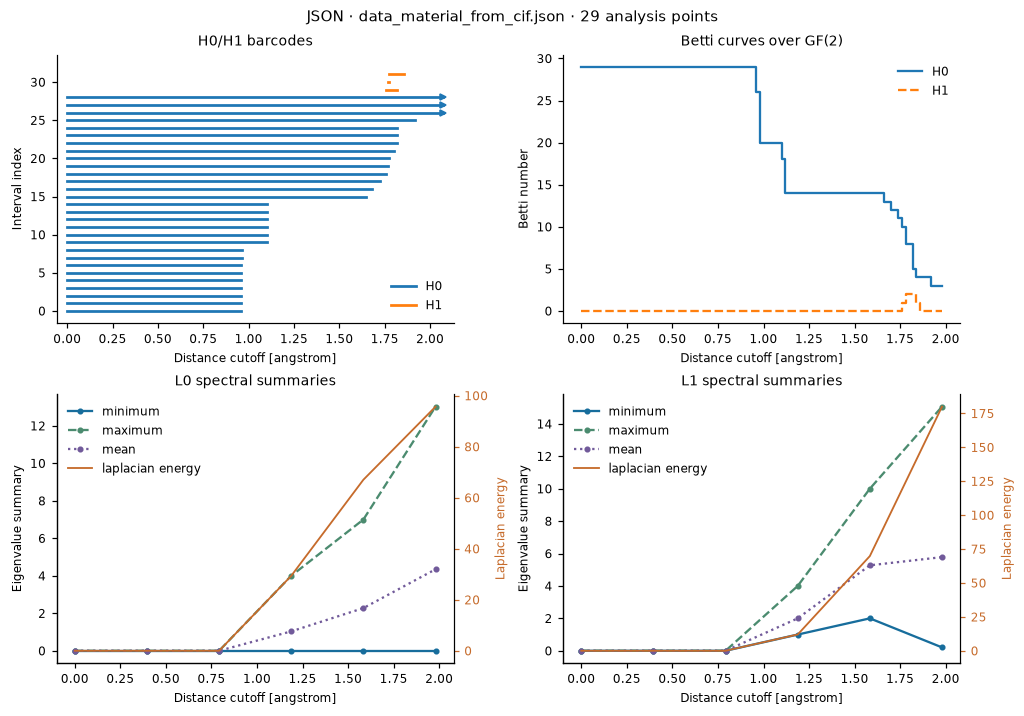

In [17]:
json_analysis = analyze_cloud(json_cloud)
plot_analysis('JSON · data_material_from_cif.json', json_analysis)

## Reading the plots

For every format, the upper row reports GF(2) persistent homology as H0/H1 barcodes and Betti curves. Each barcode is a standard line segment beginning at its recorded birth; H0 begins at zero because every vertex exists at the start of this filtration. A right-pointing arrow marks an interval that remains alive at the finite cutoff. The lower row reports summaries of the complete ordinary L0 and L1 spectra at six filtration scales.

### Laplacian and spectrum primer

For a real chain complex, the ordinary $q$-Hodge Laplacian has the form

$$L_q=\partial_q^{\ast}\partial_q+\partial_{q+1}\partial_{q+1}^{\ast}.$$

For any $q$-chain $x$, $x^{\ast}L_qx=\|\partial_qx\|^2+\|\partial_{q+1}^{\ast}x\|^2$. Therefore, every eigenvalue is nonnegative and measures the Hodge energy of its eigenmode.

| Part of the spectrum | Mathematical information | Common structural reading |
| --- | --- | --- |
| Numerical zero modes | Kernel or harmonic subspace | Topological content over the operator's coefficient field |
| Small positive eigenvalues | Lowest non-harmonic Hodge energies | Global or coherent modes, weak coupling, and possible bottlenecks |
| Large eigenvalues | High Hodge energies | Local or high-frequency variation and strongly constrained regions |

These panels use ordinary Laplacian snapshots along one filtration. They do not use the two-scale `persistent_laplacian(start=..., end=...)` operator. Their variation with cutoff is a multiscale spectral trajectory.

The words *soft*, *stiff*, *flexible*, and *interaction strength* are structural analogies unless the Laplacian weights and units encode the corresponding physics. Here they are not molecular energies in kcal/mol.

### Four spectral curves shown

At each scale, let $\lambda_1,\ldots,\lambda_n$ be the complete spectrum of L0 or L1 and let $\bar{\lambda}=n^{-1}\sum_i\lambda_i$. This notebook sets `positive_only=False`, so `min`, `max`, and `mean` include numerical zero modes. `laplacian_energy` always uses the complete full spectrum.

| Curve | Summary name | Definition | Interpretation |
| --- | --- | --- | --- |
| Minimum | `min` | $\min_i \lambda_i$ | Smallest supplied mode; with numerical nullity it lies within the zero tolerance and may display as a small signed roundoff value. |
| Maximum | `max` | $\max_i \lambda_i$ | Upper end of the spectrum. |
| Mean | `mean` | $\bar{\lambda}=n^{-1}\sum_i\lambda_i$ | Average eigenvalue, equal to the trace divided by the spectrum size. |
| Centered Laplacian energy | `laplacian_energy` | $\sum_i \lvert\lambda_i-\bar{\lambda}\rvert$ | Total absolute deviation from the spectral mean. It is classical graph Laplacian energy for a combinatorial graph L0 and the same explicitly generalized functional for Hyperdigraph L0/L1. |

When no degree-$q$ source chains exist, the corresponding operator is the complete $0\times0$ operator: its spectrum is empty and its nullity is zero. This notebook passes `empty_operator_policy='zero'`, which explicitly encodes every requested predefined summary as zero for that core-confirmed structural case. The curves therefore retain one finite value per requested degree and scale without inventing a zero eigenvalue. A nonempty all-zero operator, an empty positive-mode selection, and a partial spectrum are not treated as structural absence. The summary-level `laplacian_energy` requires a complete spectrum.

### Descriptor reference and TopoKit status

Let $\tau$ be the resolved numerical-zero tolerance, $\Lambda_+=\{\lambda_i:\lambda_i>\tau\}$, and $N_+=\lvert\Lambda_+\rvert$. Unless stated otherwise, $\lambda_i$ and $n$ refer to the modes selected by `positive_only`. The table distinguishes built-in summaries from useful custom descriptors. Interpretations describe possible information, not guaranteed physical observables.

| Descriptor | Definition | Possible information | TopoKit route |
| --- | --- | --- | --- |
| Zero multiplicity | $\#\{\lvert\lambda_i\rvert\leq\tau\}$ | Numerical nullity or harmonic content | Built in: `zero_count` |
| Positive-mode count | $N_+$ | Non-harmonic rank and size-related complexity | Built in: `positive_count` |
| Smallest positive eigenvalue | $\min \Lambda_+$ | Lowest nonzero scale, often sensitive to global coupling or bottlenecks | Built in: `min` with `positive_only=True` |
| Largest eigenvalue | $\max_i\lambda_i$ | Upper spectral scale and high-frequency structure | Built in: `max` |
| Spectral sum | $\sum_i\lambda_i$ | Total spectral magnitude or trace; strongly size dependent | Built in: `sum` |
| Spectral mean | $n^{-1}\sum_i\lambda_i$ | Average spectral scale; partly normalizes size | Built in: `mean` |
| Median and quantiles | $Q_{25},Q_{50},Q_{75}$ | Robust center and spread | `median` is built in; other quantiles and IQR are custom |
| Variance and standard deviation | $n^{-1}\sum_i(\lambda_i-\bar{\lambda})^2$ and its square root | Spectral dispersion or heterogeneity | Built in: `variance` (`spectral_variance`) and `std` |
| Raw population moment | $n^{-1}\sum_i\lambda_i^k$ | Higher orders increasingly emphasize large modes | Built in for $k=1,\ldots,4$: `moment_1`–`moment_4`; other orders use `spectral_moment` in a custom mapping |
| Unnormalized power sum | $\sum_i\lambda_i^k$ | Size-sensitive weight of large modes | Custom callable |
| Inverse positive-spectrum sum | $\sum_{\lambda_i\in\Lambda_+}1/\lambda_i$ | Strong sensitivity to small positive modes | Custom callable |
| Log pseudo-determinant | $\sum_{\lambda_i\in\Lambda_+}\log\lambda_i$ | Multiplicative scale of the positive spectrum | Custom callable |
| Spectral entropy | $-\sum_i p_i\log p_i$, $p_i=\lambda_i/\sum_j\lambda_j$ | Concentration or diversity of spectral weight | Built in: `spectral_entropy`; a zero or empty selected spectrum returns 0, and accepted tolerance-small negatives are clipped locally. Division by $\log N_+$ is custom |
| Uncentered spectral energy | $\sum_i\lvert\lambda_i\rvert$ | Total absolute spectral magnitude | Built-in summary name: `energy`; public array-level helper: `spectral_energy` |
| Centered Laplacian energy | $\sum_i\lvert\lambda_i-\bar{\lambda}\rvert$ | Total deviation from the mean | Built in: `laplacian_energy`, using a complete spectrum |
| Heat trace at diffusion scale $t$ | $\sum_i e^{-t\lambda_i}$ | Balance of low- and high-frequency modes as $t$ changes | Custom full-spectrum callable |

By default, ordinary summaries and custom callbacks receive eigenvalues above the resolved zero tolerance. Pass `positive_only=False` to use every supplied mode. The built-ins `zero_count` and `laplacian_energy` have explicit complete-spectrum behavior. Structural zero encoding applies only to a sequence of predefined summary names; a custom mapping always runs each callback, so the callback defines its own empty-input value.

### Defining a summary that is not built in

`summarize_spectrum` also accepts an ordered mapping from a descriptive name to a callable. Each callable receives its own eigenvalue-array copy and must return one real scalar. Parameter values should appear in the name because callback internals are not encoded automatically in the feature schema.

```python
example_scale = json_analysis['scales'][-1]
spectrum = json_analysis['laplacians'][example_scale][0]


def positive_inverse_sum(values):
    return float(np.sum(1.0 / values)) if values.size else np.nan


def log_pseudodeterminant(values):
    return float(np.sum(np.log(values))) if values.size else np.nan


# `positive_only=True` removes tolerance-zero modes before these callbacks run.
positive_custom = postprocessing.summarize_spectrum(
    spectrum,
    statistics={
        'positive_q25_linear': lambda values: (
            float(np.quantile(values, 0.25, method='linear'))
            if values.size else np.nan
        ),
        'inverse_positive_sum': positive_inverse_sum,
        'log_pseudodeterminant': log_pseudodeterminant,
        'positive_moment_6': lambda values: (
            postprocessing.spectral_moment(values, 6)
        ),
    },
    positive_only=True,
)

# A heat trace includes zero modes, so use a separate full-spectrum call.
# Custom callbacks receive raw supplied values; clamp tolerance-zero modes here.
diffusion_time = 1.0
zero_tolerance = 1e-10


def heat_trace(values):
    adjusted = values.copy()
    adjusted[np.abs(adjusted) <= zero_tolerance] = 0.0
    return float(np.sum(np.exp(-diffusion_time * adjusted)))


heat_custom = postprocessing.summarize_spectrum(
    spectrum,
    statistics={'heat_trace_t1': heat_trace},
    positive_only=False,
    tol=zero_tolerance,
)
```

Here `spectrum` is one complete L0 record from the JSON section. Use the same names, parameters, tolerances, and selection scope across samples. TopoKit records non-finite summaries but does not impute them for machine learning.

### Summaries of a curve across filtration scale

A per-spectrum descriptor $f(r)$ becomes a curve when evaluated across cutoff values $r$. These second-stage descriptors act on the sampled curve, not on one `SpectrumResult`.

| Curve descriptor | Definition | Possible information | Support |
| --- | --- | --- | --- |
| Area under the curve | $\int f(r)\,dr$ | Cumulative information across scale | Application-level custom calculation |
| Mean and standard deviation over scale | $\operatorname{mean}_r f$ and $\operatorname{std}_r f$ | Typical level and variation across sampled scales | Application-level custom calculation |
| Minimum and maximum values | $\min_r f(r)$ and $\max_r f(r)$ | Range attained on the sampled filtration | Application-level custom calculation |
| Total variation | $\sum_j\lvert f(r_{j+1})-f(r_j)\rvert$ | Amount of reorganization across scale | Application-level custom calculation |
| Extremum location | $r_{\min}$ or $r_{\max}$ | Characteristic scale of an extreme response | Application-level custom calculation |
| Largest sampled slope | $\max_j\lvert\Delta f_j/\Delta r_j\rvert$ | Candidate transition between sampled scales | Application-level custom calculation |

Curve-level quantities depend on the observation grid and interpolation rule. A Betti-curve integral is exact only when the grid contains every relevant birth and death event.

Further reading: [Persistent hyperdigraph homology and persistent hyperdigraph Laplacians](https://doi.org/10.3934/fods.2023010) develops the directed operators used here. [Persistent Laplacians: Properties, Algorithms and Implications](https://doi.org/10.1137/21M1435471) treats the two-scale simplicial operator and its nullity theorem.

For these ordinary real Laplacians, `zero_count` is a real-field numerical nullity. The plotted Betti curves use GF(2), so the two diagnostics need not coincide for every Hyperdigraph chain complex.